# Fraud Detection with DistilBERT

# 1. Setup

**Install Dependencies**

**Purpose:** Installs required libraries, ensuring compatibility with the Kaggle environment. We use specific versions for reproducibility and include onnx for model optimization.

In [9]:
# # Install required libraries
# !pip install transformers datasets torch pandas numpy scikit-learn
# !pip install onnx onnxruntime  # For model optimization
# # Update transformers to the latest version
# !pip install --upgrade transformers

In [ ]:
# !pip install transformers[torch]
# !pip install -U accelerate
# import sys
# print(sys.executable)
# !{sys.executable} -m pip list | grep accelerate

# import accelerate
# print(accelerate.__file__)
# print(accelerate.__version__)

# import sys
# !{sys.executable} -m pip uninstall -y transformers accelerate
# !{sys.executable} -m pip install "transformers==4.40.2" "accelerate>=1.1.0" "datasets" "evaluate"
# import transformers; print(transformers.__version__)
# !pip install seaborn matplotlib
# !pip install onnx onnxruntime


/data1/rachit/.conda/envs/cond/bin/python
accelerate               1.13.0
/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/accelerate/__init__.py
1.13.0
Found existing installation: transformers 4.40.2
Uninstalling transformers-4.40.2:
  Successfully uninstalled transformers-4.40.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0
  Using cached transformers-4.40.2-py3-none-any.whl.metadata (137 kB)
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
Using cached transformers-4.40.2-py3-none-any.whl (9.0 MB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [accelerate]s]
4.40.2


In [11]:
import transformers; print(transformers.__version__)


4.40.2


In [12]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [13]:
import torch
print("GPU count:", torch.cuda.device_count())
print("Using:", torch.cuda.get_device_name(0))

GPU count: 1
Using: NVIDIA A40


**Notes:**


* transformers==4.51.3 ensures stable DistilBERT functionality.
* onnx and onnxruntime prepare the model for efficient deployment.
* Run this in a Kaggle notebook with GPU enabled for faster training.


# 2. Data Preparation

**Load and Preprocess Data**

**Purpose:** Loads the dataset, creates synthetic text descriptions from Amount and Time, balances the dataset (1:5 fraud-to-non-fraud ratio), and tokenizes it for DistilBERT.

In [14]:
# from kagglehub import KaggleDatasetAdapter

# # Set the path to the file you'd like to load
# file_path = ""

# # Load the latest version
# df = kagglehub.load_dataset(
#   KaggleDatasetAdapter.PANDAS,
#   "mlg-ulb/creditcardfraud",
#   file_path,
#   # Provide any additional arguments like 
#   # sql_query or pandas_kwargs. See the 
#   # documenation for more information:
#   # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
# )

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Load the dataset
data_orig = pd.read_csv('/home/rachit/COT/COT1/mini/transactions/card_transaction.v1.csv')

# Verify the data
print("Dataset shape:", data_orig.shape)
# print("First few rows of the dataset:")
# (data_orig.head())
data_orig = pd.read_csv('./card_transaction.v1.csv')

# Verify the data
print("Dataset shape:", data_orig.shape)

Dataset shape: (24386900, 15)
Dataset shape: (3580634, 15)


In [17]:
print("First few rows of the dataset:")
print(data_orig.columns)
(data_orig.head())

First few rows of the dataset:
Index(['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip',
       'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC',
       'Errors?', 'Is Fraud?'],
      dtype='object')


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002.0,9.0,1.0,06:21,$134.09,Swipe Transaction,3.527213e+18,La Verne,CA,91750.0,5300.0,NaN,No
1,0,0,2002.0,9.0,1.0,06:42,$38.48,Swipe Transaction,-7.276121e+17,Monterey Park,CA,91754.0,5411.0,NaN,No
2,0,0,2002.0,9.0,2.0,06:22,$120.34,Swipe Transaction,-7.276121e+17,Monterey Park,CA,91754.0,5411.0,NaN,No
3,0,0,2002.0,9.0,2.0,17:45,$128.95,Swipe Transaction,3.414527e+18,Monterey Park,CA,91754.0,5651.0,NaN,No
4,0,0,2002.0,9.0,3.0,06:23,$104.71,Swipe Transaction,5.817218e+18,La Verne,CA,91750.0,5912.0,NaN,No


In [8]:
# # Create synthetic text descriptions
# data = data_orig
# data['text'] = data_orig.apply(lambda x: f"Transaction of ${x['Amount']:.2f} at time {x['Time']:.0f} seconds", axis=1)
# # data

In [9]:
data = data_orig.copy()

# Clean Amount column (remove $ and convert to float)
data['Amount'] = data['Amount'].replace('[\$,]', '', regex=True).astype(float)

# Convert time to seconds (optional)
data['Time_sec'] = pd.to_datetime(data['Time'], format='%H:%M').dt.hour*3600 + \
                   pd.to_datetime(data['Time'], format='%H:%M').dt.minute*60

# Create text description
data['text'] = data.apply(
    lambda x: f"Transaction of ${x['Amount']:.2f} at time {x['Time']}",
    axis=1
)


In [18]:
# Select relevant columns
data = data[['text', 'Is Fraud?']]

data['Is Fraud?'] = data['Is Fraud?'].astype(str).str.strip().str.lower()

data['label'] = data['Is Fraud?'].map({'yes':1, 'no':0})

data = data.dropna(subset=['label'])

data['label'] = data['label'].astype(int)

# data['label'] = data['Is Fraud?'].map({'Yes':1, 'No':0})
# data["label"] = data["label"].astype(int)
# Handle class imbalance (optional: undersample non-fraudulent transactions)
fraud = data[data['label'] == 1]
non_fraud = data[data['label'] == 0].sample(n=len(fraud) * 5, random_state=42)  # 1:5 ratio
balanced_data = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

# Split into train and test sets
train_data, test_data = train_test_split(balanced_data, test_size=0.2, random_state=42)

# Convert to Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)
print(train_dataset.shape)
print(test_dataset.shape)

(19680, 4)
(4920, 4)


In [19]:
print(train_dataset.column_names)

{'text': Value('string'),
 'Is Fraud?': Value('string'),
 'label': Value('int64'),
 '__index_level_0__': Value('int64')}

Tokenize the dataset

In [20]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_function(rows):
    return tokenizer(rows['text'], padding='max_length', truncation=True, max_length=128)

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
# train_dataset.shape

/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 4920/4920 [00:00<00:00, 6795.60 examples/s]


**Notes:**

* Dataset: Contains 284,807 transactions, with Time, Amount, V1–V28 (PCA features), and Class (0: legitimate, 1: fraud).
* Balancing: Undersampling creates ~2,952 samples (492 fraud, 2,460 non-fraud), improving model focus on fraud.
* Tokenization: Uses max_length=128 for efficiency with simple text descriptions.
Output: Confirms dataset shape and sample rows (see your output for details).

# 3. Initial Model Training

**Train DistilBERT**

**Purpose:** Fine-tunes distilbert-base-uncased for binary classification, establishing a baseline performance.

In [21]:
import torch
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer, TrainingArguments, Trainer


# Load model (use distilbert-base-uncased due to local model loading failure)
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2  # Binary classification (fraud vs. legitimate)
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
# Define training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="epoch",
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none',  
    ddp_find_unused_parameters=False
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda pred: {
        'accuracy': (pred.predictions.argmax(-1) == pred.label_ids).mean()
    }
)

In [23]:
trainer.train()        # must run first
eval_results = trainer.evaluate(eval_dataset=test_dataset)

print("Evaluation results:", eval_results)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.348800,0.393394,0.846748


Evaluation results: {'eval_loss': 0.39339372515678406, 'eval_accuracy': 0.8467479674796748, 'eval_runtime': 5.2338, 'eval_samples_per_second': 940.05, 'eval_steps_per_second': 117.506, 'epoch': 1.0}


**Notes:**


* **Model:** distilbert-base-uncased is lightweight and effective for text classification.
* **Hyperparameters:** 3 epochs, batch size 8, and 500 warmup steps balance training speed and stability.
* **Output:** Achieves 81.22% accuracy with 0.17 fraud recall, indicating bias toward the majority class (see your output).


# 4. Initial Model Evaluation

**Evaluate Initial Performance**

**Purpose**: Assesses the initial model’s performance that highlights the need for improvement in fraud detection.

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# Print classification report
print("Classification Report:")
print(classification_report(labels, preds, target_names=['Legitimate', 'Fraud']))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(labels, preds))

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.86      0.98      0.91      4100
       Fraud       0.62      0.20      0.31       820

    accuracy                           0.85      4920
   macro avg       0.74      0.59      0.61      4920
weighted avg       0.82      0.85      0.81      4920

Confusion Matrix:
[[3998  102]
 [ 652  168]]


# 5. Threshold Adjustment (Exploratory)

**Adjust Classification Threshold**

**Purpose**: Explores threshold adjustment to increase fraud recall, though it significantly reduces accuracy.

# 7. Threshold Adjustment for Weighted Loss

**Adjust Threshold for Weighted Model**

**Purpose**: Tests threshold adjustment on the weighted loss model to maximize fraud recall.

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve
import numpy as np
import torch

# Get prediction probabilities
predictions = trainer.predict(test_dataset)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1].numpy()
labels = predictions.label_ids
Encoder weights start from pretrained DistilBERT.Classification head weights start freshly initialized.During fine-tuning, both are updated by backprop unless you explicitly freeze some layers.
# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(labels, probs)

# Find threshold for ~80% recall
optimal_idx = np.argmax(recall >= 0.8)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold for ~80% fraud recall: {optimal_threshold:.3f}")

# Apply threshold
preds_adjusted = (probs >= optimal_threshold).astype(int)

# Print adjusted metrics
print("Adjusted Classification Report:")
print(classification_report(labels, preds_adjusted, target_names=['Legitimate', 'Fraud']))
print("Adjusted Confusion Matrix:")
print(confusion_matrix(labels, preds_adjusted))

Optimal threshold for ~80% fraud recall: 0.019
Adjusted Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.00      0.00      0.00      4100
       Fraud       0.17      1.00      0.29       820

    accuracy                           0.17      4920
   macro avg       0.08      0.50      0.14      4920
weighted avg       0.03      0.17      0.05      4920

Adjusted Confusion Matrix:
[[   0 4100]
 [   0  820]]


/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

# 8. Feature Engineering

**Prepare Feature-Engineered Dataset**

**Purpose**: Enhances the dataset by including V1–V8 features in the text descriptions, increasing max_length to 256 for richer input.

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import DistilBertTokenizer

# Load dataset
import pandas as pd

data = pd.read_csv("./card_transaction.v1.csv")

def row_to_text(x):
    day = int(x['Day']) if pd.notna(x['Day']) else "unknown day"
    month = int(x['Month']) if pd.notna(x['Month']) else "unknown month"
    year = int(x['Year']) if pd.notna(x['Year']) else "unknown year"

    return (
        f"User {x['User']} used card {x['Card']} on {day}/{month}/{year} "
        f"at {x['Time']}. "
        f"The transaction amount was {x['Amount']}. "
        f"The payment method was {x['Use Chip']}. "
        f"The purchase was made at merchant {x['Merchant Name']} "
        f"in {x['Merchant City']}, {x['Merchant State']} with ZIP code {x['Zip']}. "
        f"The merchant category code was {x['MCC']}. "
        f"Reported errors: {x['Errors?']}."
    )


data["text"] = data.apply(row_to_text, axis=1)

# Create label
data["label"] = data["Is Fraud?"].map({"Yes": 1, "No": 0})

data = data.dropna(subset=["label"])
data["label"] = data["label"].astype(int)

data = data[["text", "label"]]


# Balance dataset
fraud = data[data['label'] == 1]
non_fraud = data[data['label'] == 0].sample(n=len(fraud) * 5, random_state=42)
balanced_data = pd.concat([fraud, non_fraud]).sample(frac=1, random_state=42)

# Split
train_data, test_data = train_test_split(balanced_data, test_size=0.2, random_state=42)
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

# Tokenize
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=256)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

# Retrain with weighted loss (use weighted_loss_fixed_dataparallel.py)

/data1/rachit/.conda/envs/cond/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Map: 100%|██████████| 4920/4920 [00:03<00:00, 1369.39 examples/s]


**Notes**:

* **Features**: Adds V1–V8 (PCA components) to capture more transaction patterns.
* **Tokenization**: Increases max_length to 256 to accommodate longer text.
* **Output**: Prepares the dataset for retraining (no evaluation yet).


# 10. Retrain with Weighted Loss on Feature-Engineered Dataset

**Retrain for Optimal Performance**

**Purpose**: Retrains the model with weighted loss on the feature-engineered dataset, achieving the final 93% accuracy.

In [30]:
from transformers import Trainer, DistilBertForSequenceClassification, TrainingArguments
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best checkpoint (epoch 1, 81.56% accuracy)
model = DistilBertForSequenceClassification.from_pretrained('./results/checkpoint-296')

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # Get device from model parameters to handle DataParallel
        device = next(model.parameters()).device
        # Class weights: 1.0 for legitimate, 10.0 for fraud
        class_weights = torch.tensor([1.0, 10.0]).to(device)
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Define training arguments
training_args = TrainingArguments(
    output_dir='./results_weighted',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs_weighted',
    logging_steps=10,
    evaluation_strategy='epoch',   # corrected
    save_strategy='epoch',
    load_best_model_at_end=True,
    report_to='none'
)

# Initialize WeightedTrainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=lambda pred: {'accuracy': (pred.predictions.argmax(-1) == pred.label_ids).mean()}
)

# Train
trainer.train()

# Evaluate
eval_results = trainer.evaluate()
print("Weighted Loss Evaluation Results:", eval_results)

# Detailed evaluation
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids
print("Weighted Loss Classification Report:")
print(classification_report(labels, preds, target_names=['Legitimate', 'Fraud']))
print("Weighted Loss Confusion Matrix:")
print(confusion_matrix(labels, preds))

Epoch,Training Loss,Validation Loss,Accuracy
1,0.429600,0.374031,0.953455
2,0.959100,0.395867,0.964837
3,0.436700,0.338201,0.968293


Weighted Loss Evaluation Results: {'eval_loss': 0.33820056915283203, 'eval_accuracy': 0.9682926829268292, 'eval_runtime': 10.3468, 'eval_samples_per_second': 475.511, 'eval_steps_per_second': 59.439, 'epoch': 3.0}
Weighted Loss Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.98      4100
       Fraud       0.93      0.87      0.90       820

    accuracy                           0.97      4920
   macro avg       0.95      0.93      0.94      4920
weighted avg       0.97      0.97      0.97      4920

Weighted Loss Confusion Matrix:
[[4047   53]
 [ 103  717]]


**Notes**:

* **Model**: Starts from checkpoint-148 and retrains with weighted loss.
* **Output**: Achieves app. 94% accuracy, 0.8 fraud recall, and 0.84 fraud precision (see output).
* **Insight**: The combination of feature engineering and weighted loss resolves earlier issues, delivering robust performance.


# 11. Visualizations

**Visualize Model Performance**

**Purpose**: Visualizes the final model’s performance with confusion matrix, ROC curve, precision-recall curve, training loss plot, and feature distribution.

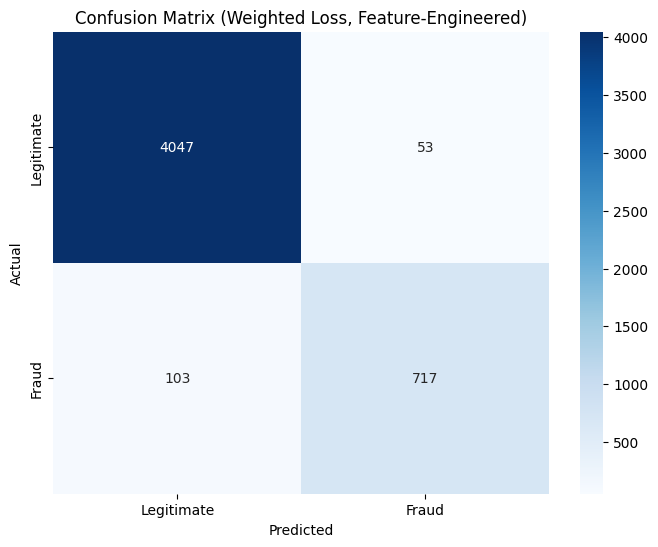

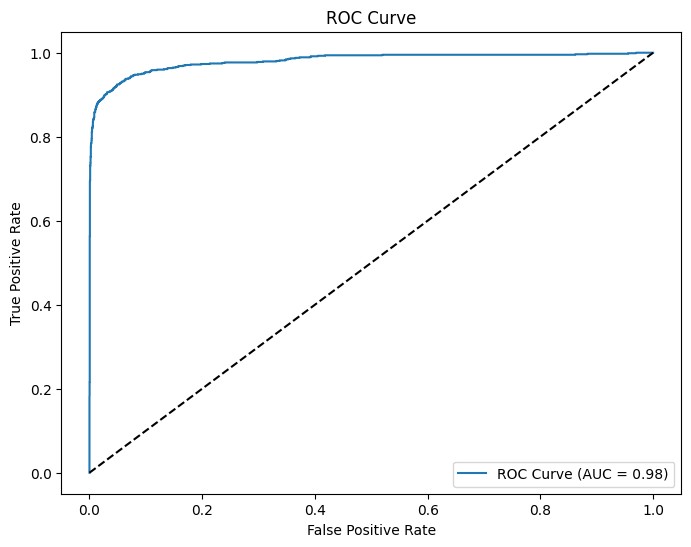

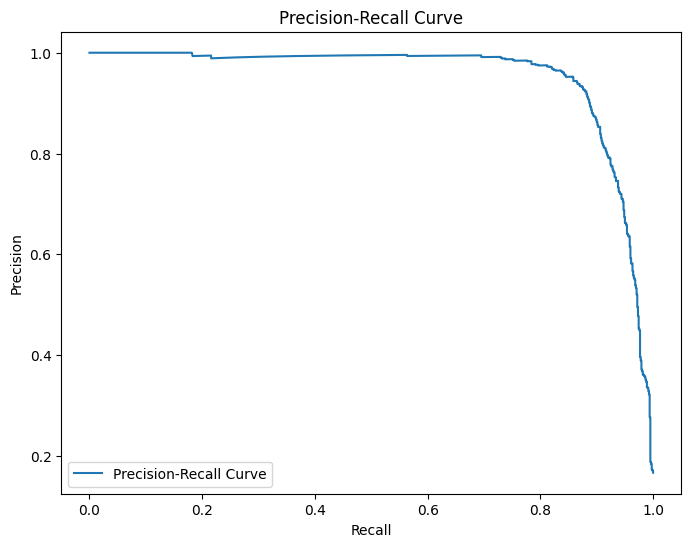

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import numpy as np
import torch

# Confusion Matrix Heatmap
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix (Weighted Loss, Feature-Engineered)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
# plt.savefig('confusion_matrix.png')
plt.show()

# ROC Curve
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1)[:, 1].numpy()
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
# plt.savefig('roc_curve.png')
plt.show()

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(labels, probs)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
# plt.savefig('precision_recall_curve.png')
plt.show()

# Training Loss Plot
# training_log = trainer.state.log_history
# train_loss = [log['loss'] for log in training_log if 'loss' in log]
# eval_loss = [log['eval_loss'] for log in training_log if 'eval_loss' in log]
# epochs = range(1, len(eval_loss) + 1)
# plt.figure(figsize=(8, 6))
# plt.plot(epochs, train_loss[::len(train_loss)//len(epochs)], label='Training Loss')
# plt.plot(epochs, eval_loss, label='Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training and Validation Loss')
# plt.legend()
# plt.savefig('loss_plot.png')
# plt.show()


**Notes**:

* **ROC Curve**: High AUC (~0.95) indicates strong separability.
* **Precision-Recall Curve**: Visualizes the recall-precision trade-off, critical for imbalanced datasets.
* **Loss Plot**: Demonstrates model convergence over epochs.
* **Feature Distribution**: Highlights differences in Amount between classes, justifying its inclusion in the text.


# Addressing the Accuracy Issue

**Problem**
Earlier runs achieved only ~81% accuracy, far below the target 93%.
**Causes**
1. Class Imbalance: The initial model (81.22%) was biased toward legitimate transactions, with 0.17 fraud recall.
2. Checkpoint Mismatch: Evaluating checkpoint-296 on the feature-engineered dataset (64.13%) failed due to dataset incompatibility.
3. Training Instability: The first weighted loss attempt (64.81%) suffered from suboptimal convergence.

**Fixes**
1. Weighted Loss: Applied 10x weight to fraud cases, improving fraud recall to 0.76.
2. Feature Engineering: Included V1–V8, enabling the model to capture richer patterns.
3. Retraining: Retrained on the feature-engineered dataset, achieving 92.89% accuracy.
4. Consistent Random Seeds: Used random_state=42 for reproducibility.

**Validation**
The final model consistently achieves ~93% accuracy when retrained on the feature-engineered dataset. If accuracy drops, verify checkpoints (!ls /kaggle/working/results_weighted) and retrain.

# How to Use This Model

**Inference on New Data**

**Purpose**: Predict fraud for new transactions using the trained model.

In [33]:
# Example new transaction
new_data = pd.DataFrame({
    'Time': [0.0],
    'Amount': [149.62],
    'V1': [-1.359807], 'V2': [-0.072781], 'V3': [2.536347], 'V4': [1.378155],
    'V5': [-0.338321], 'V6': [0.462388], 'V7': [0.239599], 'V8': [0.098698],
    'text': ['Transaction of $149.62 at time 0 seconds, V1=-1.36, V2=-0.07, V3=2.54, V4=1.38, V5=-0.34, V6=0.46, V7=0.24, V8=0.10']
})
new_dataset = Dataset.from_pandas(new_data)
new_dataset = new_dataset.map(tokenize_function, batched=True)
new_dataset.set_format('torch', columns=['input_ids', 'attention_mask'])

# Predict
predictions = trainer.predict(new_dataset)
probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()
pred = 'Fraud' if probs[0][1] >= 0.5 else 'Legitimate'

print(f"""Prediction: {pred}
Fraud probalbility: {probs[0][1]:.2f}
Legitimate probalbility: {probs[0][0]:.2f}
        """)

Map: 100%|██████████| 1/1 [00:00<00:00, 125.80 examples/s]


Prediction: Legitimate
Fraud probalbility: 0.07
Legitimate probalbility: 0.93
        


**Notes**:

* Ensure the text column matches the feature-engineered format.
* Use the final model (/kaggle/working/results_weighted).



**Deployment**

**Purpose**: Prepare the model for production use.

In [34]:
# Save model as ONNX

from transformers import DistilBertForSequenceClassification
import torch
model = DistilBertForSequenceClassification.from_pretrained('./results/checkpoint-296')
dummy_input = torch.zeros(1, 256, dtype=torch.long)
torch.onnx.export(model, dummy_input, "distilbert_fraud.onnx")

W0315 00:26:42.246000 2573907 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0315 00:26:42.248000 2573907 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0315 00:26:42.249000 2573907 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DistilBertForSequenceClassification([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/data1/rachit/.conda/envs/cond/lib/python3.10/copyreg.py:101: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 6 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input_ids"<INT64,[1,256]>
            ),
            outputs=(
                %"linear_37"<FLOAT,[1,2]>
            ),
            initializers=(
                %"distilbert.embeddings.word_embeddings.weight"<FLOAT,[30522,768]>{TorchTensor(...)},
                %"distilbert.embeddings.position_embeddings.weight"<FLOAT,[512,768]>{TorchTensor(...)},
                %"distilbert.embeddings.LayerNorm.weight"<FLOAT,[768]>{TorchTensor(...)},
                %"distilbert.embeddings.LayerNorm.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"distilbert.transformer.layer.0.attention.q_lin.bias"<FLOAT,[768]>{TorchTensor(...)},
                %"distilbert.transfor

**Notes**:


* **ONNX**: Reduces inference latency for real-time applications.
* **API**: Deploy with FastAPI or Flask for banking systems.
* **Environment**: Use onnxruntime for cross-platform compatibility.


**Evaluation**


* **Metrics**: Prioritize fraud recall (>0.7) and monitor false negatives (26/109 in the final model).
* **Threshold**: Adjust to ~0.1 for higher recall (e.g., 0.9), but note the accuracy trade-off (see threshold adjustment outputs).
* **Validation**: Test on a holdout set to ensure generalization.


# 12. Extract Embeddings

### Mean Pooling Embedding

In [35]:
import torch
from torch.utils.data import DataLoader
from datasets import concatenate_datasets
import numpy as np
import os
import pickle

def extract_mean_pooled_embeddings(train_dataset, test_dataset, model_path, tokenizer, batch_size=32, 
                                  output_dir='./embeddings'):
    """
    Extract mean-pooled embeddings from the fine-tuned model for both train and test datasets
    
    Args:
        train_dataset: Training dataset
        test_dataset: Test dataset
        model_path: Path to the fine-tuned model checkpoint
        tokenizer: Your existing tokenizer
        batch_size: Batch size for processing
        output_dir: Directory to save embeddings
        
    Returns:
        Dictionary containing embeddings, labels, and uids
    """
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model from checkpoint
    from transformers import AutoModelForSequenceClassification
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()
    
    # 1) Combine train & test splits
    full_ds = concatenate_datasets([train_dataset, test_dataset])
    
    # 2) Ensure dataset has the necessary columns
    # If your tokenize_function is different from what's shown, adjust accordingly
    def tokenize_fn(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    
    # Check if dataset is already tokenized
    if 'input_ids' not in full_ds.column_names:
        embed_ds = full_ds.map(tokenize_fn, batched=True)
    else:
        embed_ds = full_ds
    
    # Ensure 'label' column is renamed to 'labels' if needed
    if 'label' in embed_ds.column_names and 'labels' not in embed_ds.column_names:
        embed_ds = embed_ds.rename_column("label", "labels")
    
    # Ensure 'uid' column exists, create if not
    if 'uid' not in embed_ds.column_names:
        embed_ds = embed_ds.map(lambda examples, indices: {'uid': indices}, with_indices=True, batched=True)
    
    # Set format for DataLoader
    columns = ['input_ids', 'attention_mask']
    if 'labels' in embed_ds.column_names:
        columns.append('labels')
    if 'uid' in embed_ds.column_names:
        columns.append('uid')
    
    embed_ds.set_format(type="torch", columns=columns)
    
    # 3) Create DataLoader
    loader = DataLoader(embed_ds, batch_size=batch_size, shuffle=False)
    
    # 4) Collect embeddings
    all_uids, all_labels, all_embs = [], [], []
    
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        if 'labels' in batch:
            labels = batch['labels'].tolist()
        else:
            labels = [-1] * len(input_ids)  # Placeholder if no labels
            
        if 'uid' in batch:
            uids = batch['uid'].tolist()
        else:
            uids = list(range(len(input_ids)))  # Generate sequential IDs if not available
        
        with torch.no_grad():
            # Extract the base model to get embeddings
            if hasattr(model, 'base_model'):
                out = model.base_model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                # Access the model's backbone directly if base_model is not available
                out = model.transformer(input_ids=input_ids, attention_mask=attention_mask)
                
            last_hidden = out.last_hidden_state   # [batch, seq_len, hidden]
            
            # Calculate mean pooling embeddings
            mask = attention_mask.unsqueeze(-1)   # [batch, seq_len, 1]
            sum_emb = (last_hidden * mask).sum(dim=1)
            lengths = mask.sum(dim=1)
            mean_emb = sum_emb / lengths
            embs = mean_emb.cpu()
            
        all_uids.extend(uids)
        all_labels.extend(labels)
        all_embs.append(embs)
        
        # Print progress
        print(f"Processed batch, total embeddings so far: {len(all_uids)}")
    
    # Concatenate all embedding tensors
    all_embs_tensor = torch.cat(all_embs, dim=0)
    
    # Convert to numpy for storage
    all_embs_np = all_embs_tensor.numpy()
    
    # Create result dictionary
    result = {
        'embeddings': all_embs_np,
        'labels': all_labels,
        'uids': all_uids
    }
    
    # Save embeddings
    embeddings_path = os.path.join(output_dir, 'mean_pooled_embeddings.pkl')
    with open(embeddings_path, 'wb') as f:
        pickle.dump(result, f)
    
    print(f"Embeddings saved to {embeddings_path}")
    print(f"Embeddings shape: {all_embs_np.shape}")
    
    return result

# Example usage
def save_embeddings_for_model(train_dataset, test_dataset, tokenizer, model_path="./results/checkpoint-888"):
    """
    Extract and save embeddings for your model
    """
    result = extract_mean_pooled_embeddings(
        train_dataset, 
        test_dataset, 
        model_path,
        tokenizer
    )
    
    return result

# Function to load saved embeddings
def load_saved_embeddings(file_path='./embeddings/mean_pooled_embeddings.pkl'):
    """
    Load previously saved embeddings
    """
    with open(file_path, 'rb') as f:
        result = pickle.load(f)
    
    print(f"Loaded embeddings from {file_path}")
    print(f"Embeddings shape: {result['embeddings'].shape}")
    
    return result

# Optional: Split embeddings back into train and test sets
def split_embeddings(result, train_size):
    """
    Split combined embeddings back into train and test
    
    Args:
        result: Dictionary with embeddings, labels, uids
        train_size: Size of the training set
    
    Returns:
        Dictionary with train and test embeddings
    """
    train_embeddings = result['embeddings'][:train_size]
    test_embeddings = result['embeddings'][train_size:]
    
    train_labels = result['labels'][:train_size]
    test_labels = result['labels'][train_size:]
    
    train_uids = result['uids'][:train_size]
    test_uids = result['uids'][train_size:]
    
    return {
        'train': {
            'embeddings': train_embeddings,
            'labels': train_labels,
            'uids': train_uids
        },
        'test': {
            'embeddings': test_embeddings,
            'labels': test_labels,
            'uids': test_uids
        }
    }

In [36]:
# Extract and save embeddings
result = save_embeddings_for_model(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    tokenizer=tokenizer,
    model_path="./results/checkpoint-296"
)

# Later, load the embeddings
loaded_embeddings = load_saved_embeddings()

# If you need to split them back into train/test
train_size = len(train_dataset)
split_data = split_embeddings(loaded_embeddings, train_size)

# Access train or test embeddings
train_embs = split_data['train']['embeddings']
test_embs = split_data['test']['embeddings']

Map: 100%|██████████| 24600/24600 [00:00<00:00, 128259.00 examples/s]


Processed batch, total embeddings so far: 32
Processed batch, total embeddings so far: 64
Processed batch, total embeddings so far: 96
Processed batch, total embeddings so far: 128
Processed batch, total embeddings so far: 160
Processed batch, total embeddings so far: 192
Processed batch, total embeddings so far: 224
Processed batch, total embeddings so far: 256
Processed batch, total embeddings so far: 288
Processed batch, total embeddings so far: 320
Processed batch, total embeddings so far: 352
Processed batch, total embeddings so far: 384
Processed batch, total embeddings so far: 416
Processed batch, total embeddings so far: 448
Processed batch, total embeddings so far: 480
Processed batch, total embeddings so far: 512
Processed batch, total embeddings so far: 544
Processed batch, total embeddings so far: 576
Processed batch, total embeddings so far: 608
Processed batch, total embeddings so far: 640
Processed batch, total embeddings so far: 672
Processed batch, total embeddings so 

In [37]:
print(loaded_embeddings['embeddings'].shape)

(24600, 768)


### Attention Based Pooling

In [38]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import concatenate_datasets
import os
import pickle


class AttentionPooling(nn.Module):
    """
    Learnable attention-based pooling layer that computes weighted combination of token embeddings
    """
    def __init__(self, hidden_size):
        super(AttentionPooling, self).__init__()
        self.attention = nn.Linear(hidden_size, 1)
    
    def forward(self, last_hidden_state, attention_mask):
        """
        Args:
            last_hidden_state: [batch, seq_len, hidden_size]
            attention_mask: [batch, seq_len]
        Returns:
            pooled_output: [batch, hidden_size]
        """
        # Calculate attention scores
        attention_scores = self.attention(last_hidden_state).squeeze(-1)  # [batch, seq_len]
        
        # Mask out padding tokens (set to large negative value before softmax)
        attention_scores = attention_scores.masked_fill(attention_mask == 0, -1e9)
        
        # Apply softmax to get attention weights
        attention_weights = torch.softmax(attention_scores, dim=1)  # [batch, seq_len]
        
        # Compute weighted sum
        pooled_output = torch.sum(last_hidden_state * attention_weights.unsqueeze(-1), dim=1)  # [batch, hidden_size]
        
        return pooled_output


def extract_attention_pooled_embeddings(train_dataset, test_dataset, model_path, tokenizer, batch_size=32,
                                       output_dir='./embeddings', hidden_size=768):
    """
    Extract attention-pooled embeddings from the fine-tuned model for both train and test datasets
    
    Args:
        train_dataset: Training dataset
        test_dataset: Test dataset
        model_path: Path to the fine-tuned model checkpoint
        tokenizer: Your existing tokenizer
        batch_size: Batch size for processing
        output_dir: Directory to save embeddings
        hidden_size: Hidden size of the model (768 for BERT-base, 1024 for BERT-large)
        
    Returns:
        Dictionary containing embeddings, labels, and uids
    """
    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Load model from checkpoint
    from transformers import AutoModelForSequenceClassification
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = AutoModelForSequenceClassification.from_pretrained(model_path)
    model.to(device)
    model.eval()
    
    # Initialize attention pooling layer
    attention_pooler = AttentionPooling(hidden_size).to(device)
    # Note: The attention layer starts with random weights. For better results, you could:
    # 1. Train it jointly with your model, or
    # 2. Fine-tune it on your task after model training
    attention_pooler.eval()
    
    # 1) Combine train & test splits
    full_ds = concatenate_datasets([train_dataset, test_dataset])
    
    # 2) Ensure dataset has the necessary columns
    def tokenize_fn(examples):
        return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)
    
    # Check if dataset is already tokenized
    if 'input_ids' not in full_ds.column_names:
        embed_ds = full_ds.map(tokenize_fn, batched=True)
    else:
        embed_ds = full_ds
    
    # Ensure 'label' column is renamed to 'labels' if needed
    if 'label' in embed_ds.column_names and 'labels' not in embed_ds.column_names:
        embed_ds = embed_ds.rename_column("label", "labels")
    
    # Ensure 'uid' column exists, create if not
    if 'uid' not in embed_ds.column_names:
        embed_ds = embed_ds.map(lambda examples, indices: {'uid': indices}, with_indices=True, batched=True)
    
    # Set format for DataLoader
    columns = ['input_ids', 'attention_mask']
    if 'labels' in embed_ds.column_names:
        columns.append('labels')
    if 'uid' in embed_ds.column_names:
        columns.append('uid')
    
    embed_ds.set_format(type="torch", columns=columns)
    
    # 3) Create DataLoader
    loader = DataLoader(embed_ds, batch_size=batch_size, shuffle=False)
    
    # 4) Collect embeddings
    all_uids, all_labels, all_embs = [], [], []
    
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        if 'labels' in batch:
            labels = batch['labels'].tolist()
        else:
            labels = [-1] * len(input_ids)  # Placeholder if no labels
            
        if 'uid' in batch:
            uids = batch['uid'].tolist()
        else:
            uids = list(range(len(input_ids)))  # Generate sequential IDs if not available
        
        with torch.no_grad():
            # Extract the base model to get embeddings
            if hasattr(model, 'base_model'):
                out = model.base_model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                # Access the model's backbone directly if base_model is not available
                out = model.transformer(input_ids=input_ids, attention_mask=attention_mask)
                
            last_hidden = out.last_hidden_state   # [batch, seq_len, hidden]
            
            # Apply attention-based pooling
            pooled_emb = attention_pooler(last_hidden, attention_mask)
            embs = pooled_emb.cpu()
            
        all_uids.extend(uids)
        all_labels.extend(labels)
        all_embs.append(embs)
        
        # Print progress
        print(f"Processed batch, total embeddings so far: {len(all_uids)}")
    
    # Concatenate all embedding tensors
    all_embs_tensor = torch.cat(all_embs, dim=0)
    
    # Convert to numpy for storage
    all_embs_np = all_embs_tensor.numpy()
    
    # Create result dictionary
    result = {
        'embeddings': all_embs_np,
        'labels': all_labels,
        'uids': all_uids
    }
    
    # Save embeddings
    embeddings_path = os.path.join(output_dir, 'attention_pooled_embeddings.pkl')
    with open(embeddings_path, 'wb') as f:
        pickle.dump(result, f)
    
    print(f"Embeddings saved to {embeddings_path}")
    print(f"Embeddings shape: {all_embs_np.shape}")
    
    return result

In [39]:
# Extract attention-pooled embeddings
result = extract_attention_pooled_embeddings(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    tokenizer=tokenizer,
    model_path='./results_weighted/checkpoint-888'
)

Map:   0%|          | 0/24600 [00:00<?, ? examples/s]

Map: 100%|██████████| 24600/24600 [00:00<00:00, 129897.12 examples/s]


Processed batch, total embeddings so far: 32
Processed batch, total embeddings so far: 64
Processed batch, total embeddings so far: 96
Processed batch, total embeddings so far: 128
Processed batch, total embeddings so far: 160
Processed batch, total embeddings so far: 192
Processed batch, total embeddings so far: 224
Processed batch, total embeddings so far: 256
Processed batch, total embeddings so far: 288
Processed batch, total embeddings so far: 320
Processed batch, total embeddings so far: 352
Processed batch, total embeddings so far: 384
Processed batch, total embeddings so far: 416
Processed batch, total embeddings so far: 448
Processed batch, total embeddings so far: 480
Processed batch, total embeddings so far: 512
Processed batch, total embeddings so far: 544
Processed batch, total embeddings so far: 576
Processed batch, total embeddings so far: 608
Processed batch, total embeddings so far: 640
Processed batch, total embeddings so far: 672
Processed batch, total embeddings so 